In [17]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from ultralytics import YOLO

In [22]:
model = YOLO('yolov8l.pt')

100%|██████████| 83.7M/83.7M [00:22<00:00, 3.94MB/s]


In [26]:
# Load and resize image to 640x640 (YOLO default)
image = Image.open("spraylab/07024.jpg").convert("RGB")
transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor()
])
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension → shape: [1, 3, 640, 640]


In [28]:
input_tensor# Access first convolution layer
first_conv = model.model.model[0].conv  # YOLOv8 uses Conv -> BatchNorm -> SiLU in a block

# Get the output (feature maps) after Conv layer
with torch.no_grad():
    feature_maps = first_conv(input_tensor)  # shape: [1, 64, H, W]


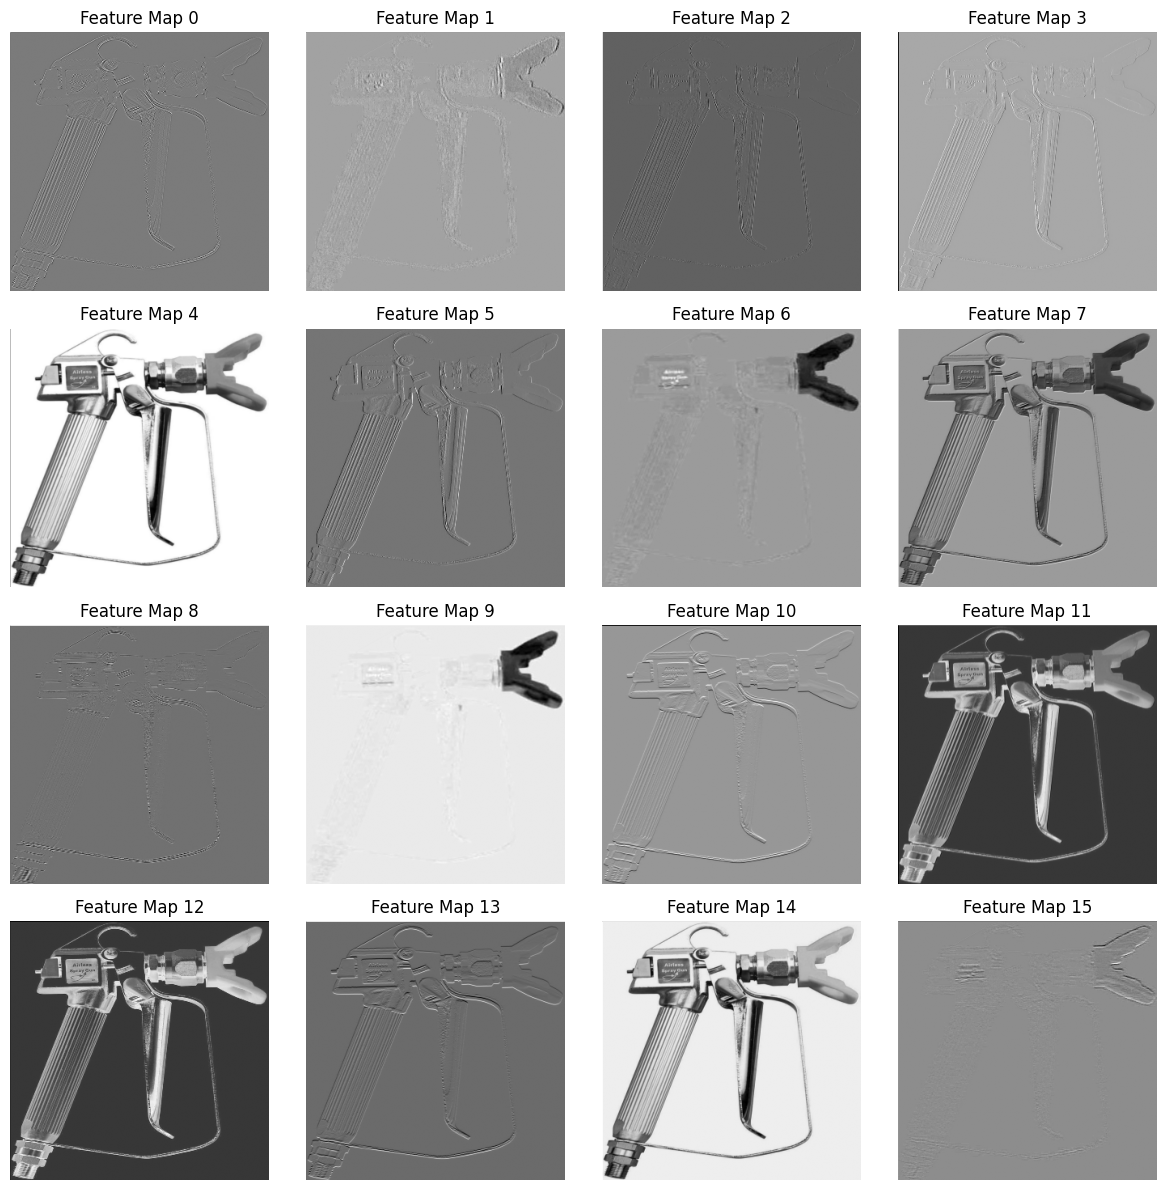

In [29]:
# Remove batch dimension and convert to numpy
feature_maps = feature_maps.squeeze(0)  # shape: [64, H, W]

# Plot first 16 feature maps in a 4x4 grid
plt.figure(figsize=(12, 12))
for i in range(16):  # You can go up to 64
    plt.subplot(4, 4, i+1)
    fmap = feature_maps[i].cpu().numpy()
    plt.imshow(fmap, cmap='gray')  # Show in grayscale
    plt.title(f"Feature Map {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()


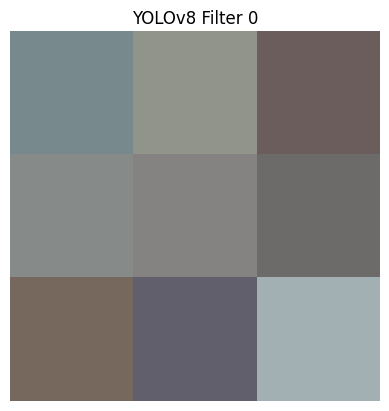

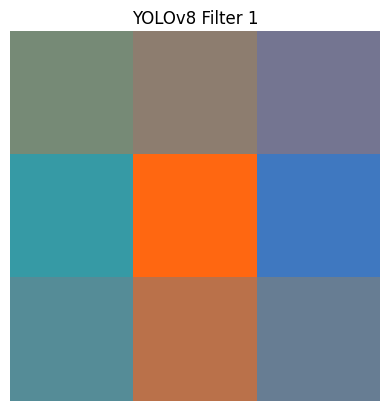

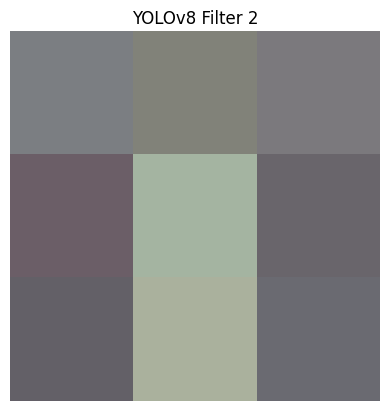

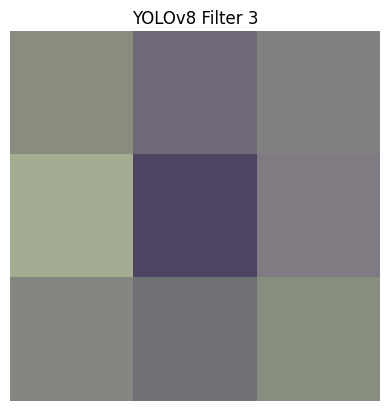

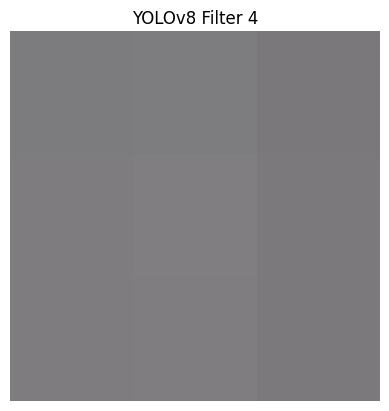

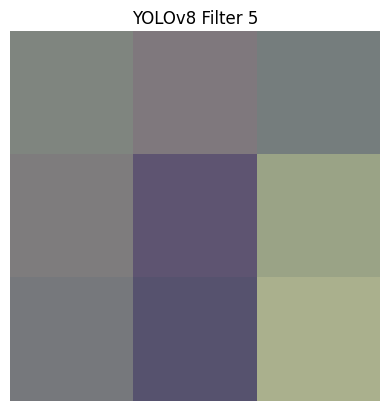

In [11]:
net = model.model

# Print model to inspect layer structure (optional)
# print(net)

# First layer: usually net.model[0]
first_conv = net.model[0]  # This is typically a Conv layer with: conv -> bn -> silu

# Get the convolutional weights (shape: [out_channels, in_channels, kH, kW])
filters = first_conv.conv.weight.data.cpu()

# Normalize filters for display (0 to 1)
filters = (filters - filters.min()) / (filters.max() - filters.min())

# Visualize first N filters
N = 6
for i in range(N):
    filt = filters[i]  # shape: (3, 3, 3)
    img = filt.permute(1, 2, 0)  # to HWC
    plt.imshow(img)
    plt.title(f"YOLOv8 Filter {i}")
    plt.axis("off")
    plt.show()

In [15]:
filters.shape

torch.Size([64, 3, 3, 3])

In [19]:
image_path = []
for file in labels_path.glob('*.jpg'):
    image_path.append(file)

image_index = 0

In [46]:
result = model(image_path[image_index])[0]
image_index += 1
# Automatically rendered image with bounding boxes
rendered_img = result.plot()  # returns a numpy array with boxes drawn

# Display the image using matplotlib
plt.imshow(rendered_img[..., ::-1])  # convert BGR to RGB
plt.axis('off')
plt.show()

IndexError: list index out of range

Convert All images from png or jpeg to jpg

In [54]:
from pathlib import Path
from PIL import Image

# Folder containing your images
image_folder = Path('datasets/dataset/images/val')

# Loop over all images with .png, .jpeg, .jpg
for img_path in image_folder.glob('*'):
    if img_path.suffix.lower() in ['.png', '.jpeg', '.jpg']:
        try:
            with Image.open(img_path) as im:
                # Convert to RGB (JPEG doesn't support transparency)
                rgb_im = im.convert('RGB')

                # Save as .jpg (same name, new suffix)
                new_path = img_path.with_suffix('.jpg')
                rgb_im.save(new_path, 'JPEG')

                # Optional: remove original if it's not already .jpg
                if img_path.suffix.lower() != '.jpg':
                    img_path.unlink()

                print(f"Converted: {img_path.name} → {new_path.name}")
        except Exception as e:
            print(f"Error converting {img_path.name}: {e}")


Converted: 00a1895e-aab13.jpg → 00a1895e-aab13.jpg
Converted: 07078.jpeg → 07078.jpg
Converted: 07079.jpeg → 07079.jpg
Converted: 07080.jpeg → 07080.jpg
Converted: 07081.jpeg → 07081.jpg
Converted: 07082.jpeg → 07082.jpg
Converted: 07083.jpeg → 07083.jpg
Converted: 07084.jpeg → 07084.jpg
Converted: 07085.jpeg → 07085.jpg
Converted: 07086.jpeg → 07086.jpg
Converted: 07087.jpeg → 07087.jpg
Converted: 07088.jpeg → 07088.jpg
Converted: 07089.jpeg → 07089.jpg
Converted: 07090.jpeg → 07090.jpg
Converted: 07091.jpeg → 07091.jpg
Converted: 07092.jpeg → 07092.jpg
Converted: 07093.jpeg → 07093.jpg
Converted: 07094.jpeg → 07094.jpg
Converted: 07447.png → 07447.jpg
Converted: 07448.png → 07448.jpg
Converted: 07449.png → 07449.jpg
Converted: 07450.png → 07450.jpg
Converted: 07451.png → 07451.jpg
Converted: 07452.png → 07452.jpg
Converted: 07453.png → 07453.jpg
Converted: 07454.png → 07454.jpg
Converted: 07455.png → 07455.jpg
Converted: 07456.png → 07456.jpg
Converted: 07457.png → 07457.jpg
Converte

<font color='Tomato'>Resize Image from random Dimentions to 640*640</font>

In [4]:
from pathlib import Path
from PIL import Image

image_folder = Path('output/images')
target_size = 1024
valid_exts = ['.jpg', '.jpeg']

for img_path in image_folder.glob('*'):
    if img_path.suffix.lower() in valid_exts:
        with Image.open(img_path) as img:
            width, height = img.size

            # Skip small images
            if width <= target_size and height <= target_size:
                print(f"Skipping small image: {img_path.name}")
                continue

            # Resize while preserving aspect ratio
            if width >= height:
                new_width = target_size
                new_height = int(height * (target_size / width))
            else:
                new_height = target_size
                new_width = int(width * (target_size / height))

            resized_img = img.resize((new_width, new_height), Image.LANCZOS)

            # Save with high quality
            resized_img.save(img_path, quality=95, optimize=True, exif=img.info.get('exif', b''))

            print(f'Resized and overwritten: {img_path.name}')


Resized and overwritten: synthetic3_0000.jpg
Resized and overwritten: synthetic3_0001.jpg
Resized and overwritten: synthetic3_0002.jpg
Resized and overwritten: synthetic3_0003.jpg
Skipping small image: synthetic3_0004.jpg
Resized and overwritten: synthetic3_0005.jpg
Skipping small image: synthetic3_0006.jpg
Resized and overwritten: synthetic3_0007.jpg
Skipping small image: synthetic3_0008.jpg
Resized and overwritten: synthetic3_0009.jpg
Resized and overwritten: synthetic3_0010.jpg
Resized and overwritten: synthetic3_0011.jpg
Resized and overwritten: synthetic3_0012.jpg
Resized and overwritten: synthetic3_0013.jpg
Resized and overwritten: synthetic3_0014.jpg
Resized and overwritten: synthetic3_0015.jpg
Resized and overwritten: synthetic3_0016.jpg
Resized and overwritten: synthetic3_0017.jpg
Resized and overwritten: synthetic3_0018.jpg
Resized and overwritten: synthetic3_0019.jpg
Resized and overwritten: synthetic3_0020.jpg
Resized and overwritten: synthetic3_0021.jpg
Resized and overwri

In [6]:
from pathlib import Path

label_folder = Path('datasets/dataset/labels/train')

class_detection = [0, 0, 0, 0, 0, 0, 0]  # List for 7 classes

for file in label_folder.glob('*-*.txt'):
    with file.open('r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                print(file)
                continue
            class_id = int(parts[0])          # Convert to int
            class_detection[class_id] += 1    # Increment count

print(class_detection)


[419, 32, 48, 11, 176, 16, 33]


<font color='Tomato'>Add Logo on Background Image</font>

In [3]:
import cv2
import numpy as np
import os
import random

# Parameters
logos_folder = 'Zlogo'
backgrounds_folder = 'Zbackground'
output_dir = 'output'
image_output_dir = os.path.join(output_dir, 'images')
label_output_dir = os.path.join(output_dir, 'labels')
num_images = 50  # Total synthetic images to generate
class_id = 2     # YOLO class ID for logo
MIN_FADE_STRENGTH = 0.0
MAX_FADE_STRENGTH = 0.0
LOGO_SCALE_MAX = 0.3
LOGO_SCALE_MIN = 0.1

os.makedirs(image_output_dir, exist_ok=True)
os.makedirs(label_output_dir, exist_ok=True)

# Load logo and background paths
logo_paths = [os.path.join(logos_folder, f) for f in os.listdir(logos_folder) if f.lower().endswith('.png')]
background_paths = [os.path.join(backgrounds_folder, f) for f in os.listdir(backgrounds_folder) if f.lower().endswith(('.jpg', '.png'))]

print(logo_paths)

def get_random_transform(bg_size, logo_size):
    bg_h, bg_w = bg_size
    logo_h, logo_w = logo_size
    scale_target = random.uniform(*(LOGO_SCALE_MIN,LOGO_SCALE_MAX))

    # Target logo area as % of background area
    target_area = scale_target * (bg_w * bg_h)
    aspect_ratio = logo_w / logo_h

    # Derive target width & height maintaining aspect ratio
    target_h = int((target_area / aspect_ratio) ** 0.5)
    target_w = int(target_h * aspect_ratio)

    angle = random.uniform(0, 360)
    return (target_w, target_h), angle

def rotate_and_scale_logo(logo, target_size, angle):
    target_w, target_h = target_size
    logo_resized = cv2.resize(logo, (target_w, target_h), interpolation=cv2.INTER_AREA)

    if logo_resized.shape[2] == 4:
        b, g, r, a = cv2.split(logo_resized)
        logo_rgb = cv2.merge((b, g, r))
        mask = a
    else:
        logo_rgb = logo_resized
        mask = np.ones(logo_resized.shape[:2], dtype=np.uint8) * 255

    h, w = logo_rgb.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    rotated_rgb = cv2.warpAffine(logo_rgb, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    rotated_mask = cv2.warpAffine(mask, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    rotated_logo = cv2.merge((rotated_rgb, rotated_mask))
    return rotated_logo , rotated_mask

def is_overlapping(box1, box2, padding=10):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    return not (x1 + w1 + padding < x2 or x2 + w2 + padding < x1 or
                y1 + h1 + padding < y2 or y2 + h2 + padding < y1)

def add_noise_to_logo(logo_rgb, noise_level=0.05):
    noise = np.random.normal(0, noise_level, logo_rgb.shape).astype(np.float32)
    noisy_logo = logo_rgb + noise
    return np.clip(noisy_logo, 0, 1)

def place_logo(bg, logo_transformed, existing_boxes):
    fade_strength = random.uniform(MIN_FADE_STRENGTH, MAX_FADE_STRENGTH)
    h, w = logo_transformed.shape[:2]
    bg_h, bg_w = bg.shape[:2]

    if h >= bg_h or w >= bg_w:
        return None

    for _ in range(50):
        x = random.randint(0, bg_w - w)
        y = random.randint(0, bg_h - h)
        new_box = (x, y, w, h)

        if all(not is_overlapping(new_box, b) for b in existing_boxes):
            roi = bg[y:y+h, x:x+w].astype(np.float32) / 255.0

            if logo_transformed.shape[2] == 4:
                alpha = logo_transformed[:, :, 3].astype(np.float32) / 255.0
                alpha_3ch = np.stack([alpha] * 3, axis=2)
                logo_rgb = logo_transformed[:, :, :3].astype(np.float32) / 255.0

                logo_rgb = add_noise_to_logo(logo_rgb, noise_level=0.03)

                overlay_blend = 2 * roi * logo_rgb + (roi ** 2) * (1 - 2 * logo_rgb)
                final_logo = (1 - fade_strength) * logo_rgb + fade_strength * overlay_blend

                out = roi * (1 - alpha_3ch) + final_logo * alpha_3ch
                bg[y:y+h, x:x+w] = (np.clip(out, 0, 1) * 255).astype(np.uint8)

                # === Bounding Box from Mask ===
                coords = cv2.findNonZero((alpha * 255).astype(np.uint8))
                x_mask, y_mask, w_mask, h_mask = cv2.boundingRect(coords)
                return (x + x_mask, y + y_mask, w_mask, h_mask)

            else:
                bg[y:y+h, x:x+w] = logo_transformed[:, :, :3]
                return (x, y, w, h)

    return None


# Main loop to generate images
for i in range(num_images):
    bg_path = random.choice(background_paths)
    bg = cv2.imread(bg_path)
    if bg is None:
        continue
    bg_h, bg_w = bg.shape[:2]
    boxes = []
    labels = []

    num_logos = random.randint(1, 3)
    for _ in range(num_logos):
        logo_path = random.choice(logo_paths)
        logo_img = cv2.imread(logo_path, cv2.IMREAD_UNCHANGED)
        if logo_img is None or logo_img.shape[2] != 4:
            continue

        (target_w, target_h), angle = get_random_transform(bg.shape[:2], logo_img.shape[:2])
        transformed_logo, rotated_mask = rotate_and_scale_logo(logo_img, (target_w, target_h), angle)


        # Extra safety check
        if transformed_logo.shape[0] >= bg.shape[0] or transformed_logo.shape[1] >= bg.shape[1]:
            continue


        
        placed = place_logo(bg, transformed_logo, boxes)
        if placed:
            x, y, w, h = placed
            boxes.append((x, y, w, h))

            # YOLO normalized format
            xc = (x + w / 2) / bg_w
            yc = (y + h / 2) / bg_h
            wn = w / bg_w
            hn = h / bg_h
            labels.append(f"{class_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")

    if labels:
        img_name = f"synthetic3_{i:04d}.jpg"
        label_name = f"synthetic3_{i:04d}.txt"

        cv2.imwrite(os.path.join(image_output_dir, img_name), bg)
        with open(os.path.join(label_output_dir, label_name), 'w') as f:
            f.write("\n".join(labels))


['Zlogo\\erasebg-transformed (10).png', 'Zlogo\\erasebg-transformed (11).png', 'Zlogo\\erasebg-transformed (13).png', 'Zlogo\\erasebg-transformed (14).png', 'Zlogo\\erasebg-transformed (15).png', 'Zlogo\\erasebg-transformed (2).png', 'Zlogo\\erasebg-transformed (3).png', 'Zlogo\\erasebg-transformed (4).png', 'Zlogo\\erasebg-transformed (5).png', 'Zlogo\\erasebg-transformed (6).png', 'Zlogo\\erasebg-transformed (7).png', 'Zlogo\\erasebg-transformed (8).png', 'Zlogo\\erasebg-transformed (9).png', 'Zlogo\\erasebg-transformed.png', 'Zlogo\\erasebg-transformed_1.png']


In [20]:
import os
import cv2
import matplotlib.pyplot as plt

# Update these paths
image_dir = 'datasets/dataset/images/train'
label_dir = 'datasets/dataset/labels/train'

# Optional: class names (for display)
class_names = ['ap', 'bhs', 'sander', 'isafe', 'shirt', 'spray', 'machine']

# Define a color palette (RGB tuples)
COLOR_PALETTE = [
    (255, 0, 0),     # Red
    (0, 255, 0),     # Green
    (0, 0, 255),     # Blue
    (255, 255, 0),   # Yellow
    (255, 0, 255),   # Magenta
    (0, 255, 255),   # Cyan
    (255, 165, 0),   # Orange
    (128, 0, 128),   # Purple
    (0, 128, 128),   # Teal
    (128, 128, 0)    # Olive
]

def get_color_for_class(class_id):
    return COLOR_PALETTE[class_id % len(COLOR_PALETTE)]

# List image files
image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))])

In [1]:
for image_file in image_files[0:1]:
    image_path = os.path.join(image_dir, image_file)
    label_path = os.path.join(label_dir, os.path.splitext(image_file)[0] + '.txt')

    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read {image_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for matplotlib
    h, w = img.shape[:2]

    class_found = False

    # Draw bounding boxes from label file
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id, xc, yc, bw, bh = map(float, parts)
                class_id = int(class_id)
                if class_id == 2 or class_id == 4 :
                    class_found = True
                    x1 = int((xc - bw / 2) * w)
                    y1 = int((yc - bh / 2) * h)
                    x2 = int((xc + bw / 2) * w)
                    y2 = int((yc + bh / 2) * h)

                    color = get_color_for_class(class_id)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

                    label = class_names[class_id] if class_names and class_id < len(class_names) else str(class_id)
                    cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    if not class_found:
        continue

    # Display inline
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(image_file)
    plt.axis('off')
    plt.show()

NameError: name 'image_files' is not defined

<font color='Tomato'>Delete Images without Labels</font>

In [6]:
import os

image_folder = 'Screenshots'
label_folder = 'Screenshots_labels'
valid_extensions = ('.jpg', '.jpeg', '.png')
should_delete = True  # Set to True to actually delete files

deleted_images = 0
deleted_labels = 0

image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(valid_extensions)]

for image_file in image_files:
    image_path = os.path.join(image_folder, image_file)
    base_name = os.path.splitext(image_file)[0]
    label_file = base_name + ".txt"
    label_path = os.path.join(label_folder, label_file)

    # 1. Label file does not exist
    if not os.path.exists(label_path):
        print(f"[MISSING LABEL] Deleting image: {image_file}")
        if should_delete:
            os.remove(image_path)
        deleted_images += 1
        continue

# Final summary
print(f"\n✅ Done. Deleted {deleted_images} image(s) and {deleted_labels} label(s).")
if not should_delete:
    print("🧪 Test mode: No files were actually deleted. Set `should_delete = True` to apply changes.")


[MISSING LABEL] Deleting image: vid4.jpg

✅ Done. Deleted 1 image(s) and 0 label(s).


<font color='Tomato'>Delete Labels without image</font>

In [2]:
import os
from pathlib import Path

label_dir = Path('datasets/dataset/labels/train')
image_dir = Path('datasets/dataset/images/train')

for lbl in label_dir.glob('*.txt'):
    image_path = image_dir / (lbl.stem + '.jpg')
    if image_path.exists():
        pass
    else:
        print(image_path)
        lbl.unlink()



datasets\dataset\images\train\dwnl_00000.jpg
datasets\dataset\images\train\dwnl_00010.jpg


<font color='Tomato'>Extract Frame as Image from Video</font>

In [1]:
import cv2
import os

# === CONFIGURATION ===
video_path = 'sprayvid/videoplayback.mp4'     # Path to your video file
output_dir = 'spraylab'       # Directory to save extracted frames
frame_interval = 30                # Extract every 30th frame
start_number = 0                   # Starting image number (e.g., 1 → yt00001.jpg)

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Open video
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video: {video_path}")

frame_count = 0
image_count = start_number

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % frame_interval == 0:
        filename = f"yt_s{image_count:05d}.jpg"
        filepath = os.path.join(output_dir, filename)
        cv2.imwrite(filepath, frame)
        # print(f"Saved: {filepath}")
        image_count += 1

    frame_count += 1

cap.release()
print("✅ Done.")


✅ Done.


<font color='Tomato'>Generate Label file from Images</font>

In [14]:
import os
from ultralytics import YOLO

# === USER SETTINGS ===
model_path = "runs/thirdrun_noaug.pt"  # Path to your YOLO model
input_folder = "book_pages"  # Folder with original images
output_label_folder = "page_label"  # Folder to save YOLO .txt label files

# === CREATE OUTPUT FOLDER IF NOT EXISTS ===
os.makedirs(output_label_folder, exist_ok=True)

# === LOAD YOLO MODEL ===
model = YOLO(model_path)

# === SUPPORTED IMAGE EXTENSIONS ===
image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']

cur_image = 0

# === LOOP THROUGH ALL IMAGES ===
for filename in os.listdir(input_folder):
    ext = os.path.splitext(filename)[1].lower()
    if ext in image_extensions:
        input_path = os.path.join(input_folder, filename)
        name_wo_ext = os.path.splitext(filename)[0]
        label_path = os.path.join(output_label_folder, f"{name_wo_ext}.txt")

        # Run detection
        results = model(input_path, verbose=False)

        # Get image shape to normalize bounding boxes
        img_shape = results[0].orig_shape  # (height, width)

        # Open label file to write
        with open(label_path, 'w') as f:
            for box in results[0].boxes:
                cls_id = int(box.cls.item())  # class index
                x_center, y_center, w, h = box.xywhn[0]  # normalized xywh
                f.write(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")
        
        cur_image += 1

        print(f"✅ Saved: {cur_image}")

print("🎯 All YOLO label files saved in:", output_label_folder)


✅ Saved: 1
✅ Saved: 2
✅ Saved: 3
✅ Saved: 4
✅ Saved: 5
✅ Saved: 6
✅ Saved: 7
✅ Saved: 8
✅ Saved: 9
✅ Saved: 10
✅ Saved: 11
✅ Saved: 12
✅ Saved: 13
✅ Saved: 14
✅ Saved: 15
✅ Saved: 16
✅ Saved: 17
✅ Saved: 18
✅ Saved: 19
✅ Saved: 20
✅ Saved: 21
✅ Saved: 22
✅ Saved: 23
✅ Saved: 24
✅ Saved: 25
✅ Saved: 26
✅ Saved: 27
✅ Saved: 28
✅ Saved: 29
✅ Saved: 30
✅ Saved: 31
✅ Saved: 32
✅ Saved: 33
✅ Saved: 34
✅ Saved: 35
✅ Saved: 36
✅ Saved: 37
✅ Saved: 38
✅ Saved: 39
✅ Saved: 40
✅ Saved: 41
✅ Saved: 42
✅ Saved: 43
✅ Saved: 44
✅ Saved: 45
✅ Saved: 46
✅ Saved: 47
✅ Saved: 48
✅ Saved: 49
✅ Saved: 50
✅ Saved: 51
✅ Saved: 52
✅ Saved: 53
✅ Saved: 54
✅ Saved: 55
✅ Saved: 56
✅ Saved: 57
✅ Saved: 58
🎯 All YOLO label files saved in: page_label


Rename both Label File and Imagefile

In [17]:
from pathlib import Path

image_folder = Path("book_pages")
label_folder = Path("page_label")

for idx, image in enumerate(image_folder.glob('*'), start=0):
    new_name = f'dwnl_{idx:05d}'
    lbl_file = label_folder / (image.stem + '.txt')

    if lbl_file.exists():
        # Rename label
        lbl_file.rename(label_folder / f"{new_name}.txt")

        # Rename image
        image.rename(image_folder / f"{new_name}{image.suffix}")
    else:
        print(f'Label not found for {image.name} — skipping.')


Label not found for 000001.jpg — skipping.


In [2]:
from PIL import Image
import os


def split_image_vertically(image_path, output_folder, num_splits=15):
    # Open the image
    image = Image.open(image_path)
    width, height = image.size

    # Width of each vertical strip
    split_width = width // num_splits

    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Split and save
    for i in range(num_splits):
        left = i * split_width
        right = (i + 1) * split_width if i < num_splits - 1 else width  # include remaining pixels in last strip
        cropped_img = image.crop((left, 0, right, height))
        cropped_img.save(os.path.join(output_folder, f"part_{i+1:02d}.jpg"))

    print(f"Saved {num_splits} vertical strips in: {output_folder}")

# Example usage
split_image_vertically("sprayvid/imby.jpeg", "sprayvid")


Saved 15 vertical strips in: sprayvid


In [ ]:
from pathlib import Path
import shutil

# Set your paths
destination_folder = Path("datasets/dataset/images/val")
source_folder = Path("datasets/dataset_before640/images/val")

# Define valid image extensions
valid_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']

cnt = 0

# Loop through each image in destination folder
for dest_img in destination_folder.glob("*"):
    if dest_img.suffix.lower() in valid_exts:
        src_img = source_folder / dest_img.name
        if src_img.exists():
            # Copy and overwrite
            # shutil.copy2(src_img, dest_img)
            print(f"Replaced: {dest_img.name}")
            cnt += 1
        else:
            print(f"No match found in source for: {dest_img.name}")
print(cnt)


Replaced: 00a1895e-aab13.jpg
Replaced: 08ead82e-dab12.jpg
Replaced: 0e64e88d-ca23.jpg
Replaced: 114b13e0-ba2.jpg
Replaced: 1548dc5f-dab73.jpg
Replaced: 1d0b34ec-cab18.jpg
Replaced: 260ddf33-dab47.jpg
Replaced: 296486f5-aa14.jpg
Replaced: 2ae73d6b-ea18.jpg
Replaced: 313c3e54-ba36.jpg
Replaced: 36e2b313-ba23.jpg
Replaced: 3f38abe2-ca5.jpg
Replaced: 4f7e932e-ba31.jpg
Replaced: 53602748-eab1.jpg
Replaced: 5616a921-dab68.jpg
Replaced: 5c3029d9-dab75.jpg
Replaced: 5ca557ff-dab79.jpg
Replaced: 61e131ed-ba24.jpg
Replaced: 6651d79a-dab74.jpg
Replaced: 6fee4ee5-dab61.jpg
Replaced: 73c8b18e-ca11.jpg
Replaced: 786fbbbf-dab13.jpg
Replaced: 7c03fe36-ca17.jpg
Replaced: 7d6c658b-aab20.jpg
Replaced: 83c46158-eab7.jpg
Replaced: 9482f7a6-dab20.jpg
Replaced: 969529d7-ea7.jpg
Replaced: 9ae067c2-ba4.jpg
Replaced: 9ffbbfdc-dab26.jpg
Replaced: a834e89b-aa18.jpg
Replaced: ac4fc11b-cab21.jpg
Replaced: ad36e203-ca29.jpg
Replaced: b0411300-ea4.jpg
Replaced: b4dfa8f9-dab22.jpg
Replaced: bd89c3ca-ca7.jpg
Replaced: 

In [6]:
from itertools import groupby

str = 'aaabaaba'

for char, i in groupby(str):
    print(char,list(i))



a ['a', 'a', 'a']
b ['b']
a ['a', 'a']
b ['b']
a ['a']
